<a href="https://colab.research.google.com/github/JoudySaleh-IT/IT461-MovieGenreClassification/blob/main/movie_genre_classification_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Genre Classification from Plot Summaries
### IT461 Practical Machine Learning Project
This notebook presents an end-to-end workflow for movie genre classification using textual plot summaries.

In [1]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

import joblib

# 1. Check Available Files
In this section, we verify that the required dataset files are available in the working directory.

In [2]:
!ls -lh

total 25M
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data
-rw-r--r-- 1 root root 9.0M May  2 15:03 test_data_solution.txt
-rw-r--r-- 1 root root 8.0M May  2 15:03 test_data.txt
-rw-r--r-- 1 root root 7.0M May  2 15:03 train_data.txt


# 2. Preview Raw Training Data
Before loading the dataset formally, we inspect a few raw lines to understand the original file format.

In [3]:
with open("train_data.txt", "r", encoding="latin-1") as f:
    for i in range(5):
        print(repr(f.readline()))

'1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.\n'
'2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.\n'
'3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect t

# 3. Define Data Loading Functions
These helper functions read the training, test, and test solution files and convert them into pandas DataFrames.

In [4]:
def load_train_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=3)
            if len(parts) == 4:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Genre", "Description"])


def load_test_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=2)
            if len(parts) == 3:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Description"])


def load_test_solution(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=1)
            if len(parts) == 2:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Genre"])

# 4. Load the Dataset
We now load the training, test, and test-solution files into DataFrames.

In [5]:
train_df = load_train_data("train_data.txt")
test_df = load_test_data("test_data.txt")
test_solution_df = load_test_solution("test_data_solution.txt")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test solution shape:", test_solution_df.shape)

Train shape: (11179, 4)
Test shape: (13154, 3)
Test solution shape: (14515, 2)


# 5. Inspect the Training Data
We inspect the first few rows to understand the dataset structure and verify that it was loaded correctly.

In [6]:
train_df.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 6. Dataset Information and Missing Values
This section shows the data types, missing values, and the number of unique genre classes.

In [7]:
print(train_df.info())
print("\nMissing values:\n", train_df.isnull().sum())
print("\nNumber of unique genres:", train_df["Genre"].nunique())
print("\nGenres:\n", sorted(train_df["Genre"].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11179 entries, 0 to 11178
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           11179 non-null  object
 1   Title        11179 non-null  object
 2   Genre        11179 non-null  object
 3   Description  11179 non-null  object
dtypes: object(4)
memory usage: 349.5+ KB
None

Missing values:
 ID             0
Title          0
Genre          0
Description    0
dtype: int64

Number of unique genres: 27

Genres:
 ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


# 7. Summary Statistics
To better understand the dataset, we present key summary statistics describing its structure and scale.

In [8]:
summary_stats = pd.DataFrame({
    "Attribute": [
        "Task Type",
        "Number of Training Examples",
        "Number of Test Examples",
        "Number of Classes (Genres)",
        "Input Feature Type",
        "Output Label"
    ],
    "Value": [
        "Multi-class text classification",
        len(train_df),
        len(test_df),
        train_df["Genre"].nunique(),
        "Text (movie plot summary)",
        "Single genre"
    ]
})

summary_stats

,Attribute,Value
0,Task Type,Multi-class text classification
1,Number of Training Examples,11179
2,Number of Test Examples,13154
3,Number of Classes (Genres),27
4,Input Feature Type,Text (movie plot summary)
5,Output Label,Single genre


# 8. Representative Examples
Below are a few representative examples from the training dataset, including movie title, genre, and description.

In [9]:
train_df[["Title", "Genre", "Description"]].head(5)

,Title,Genre,Description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 9. Text Preprocessing Function
Since machine learning models cannot process raw text directly, we define a cleaning function to normalize the descriptions.

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 10. Apply Text Preprocessing
We apply the preprocessing function to both the training and test descriptions.

In [11]:
train_df["Clean_Title"] = train_df["Title"].apply(clean_text)
train_df["Clean_Description"] = train_df["Description"].apply(clean_text)

test_df["Clean_Title"] = test_df["Title"].apply(clean_text)
test_df["Clean_Description"] = test_df["Description"].apply(clean_text)

train_df["Full_Text"] = train_df["Clean_Title"] + " " + train_df["Clean_Description"]
test_df["Full_Text"] = test_df["Clean_Title"] + " " + test_df["Clean_Description"]

train_df[["Title", "Clean_Title", "Description", "Clean_Description", "Full_Text"]].head()

,Title,Clean_Title,Description,Clean_Description,Full_Text
0,Oscar et la dame rose (2009),oscar et la dame rose,Listening in to a conversation between his doc...,listening in to a conversation between his doc...,oscar et la dame rose listening in to a conver...
1,Cupid (1997),cupid,A brother and sister with a past incestuous re...,a brother and sister with a past incestuous re...,cupid a brother and sister with a past incestu...
2,"Young, Wild and Wonderful (1980)",young wild and wonderful,As the bus empties the students for their fiel...,as the bus empties the students for their fiel...,young wild and wonderful as the bus empties th...
3,The Secret Sin (1915),the secret sin,To help their unemployed father make ends meet...,to help their unemployed father make ends meet...,the secret sin to help their unemployed father...
4,The Unrecovered (2007),the unrecovered,The film's title refers not only to the un-rec...,the films title refers not only to the unrecov...,the unrecovered the films title refers not onl...


# 11. Analyze Description Lengths
We examine the distribution of movie description lengths to better understand variation in input size.

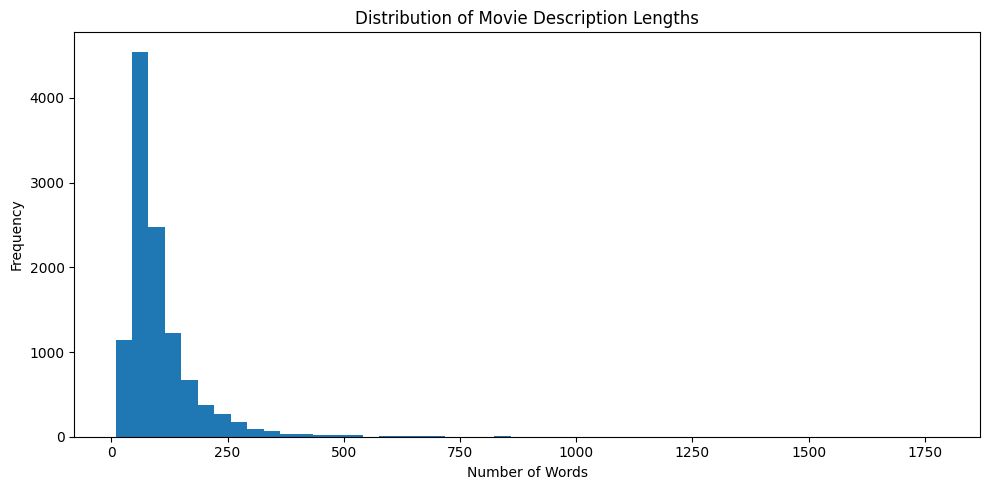

In [12]:
train_df["desc_length"] = train_df["Clean_Description"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
plt.hist(train_df["desc_length"], bins=50)
plt.title("Distribution of Movie Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 12. Class Distribution Analysis
This plot shows the distribution of genre classes in the training set and highlights possible class imbalance.

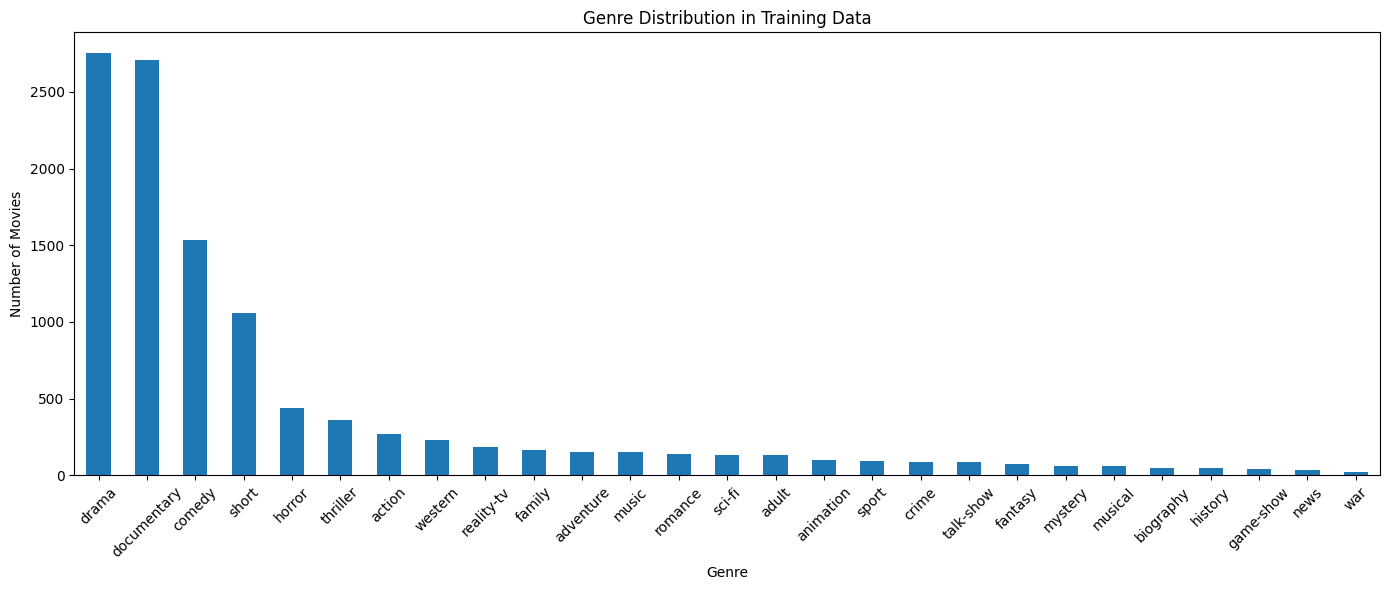

In [13]:
plt.figure(figsize=(14,6))
train_df["Genre"].value_counts().plot(kind="bar")
plt.title("Genre Distribution in Training Data")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Most Common Words in Plot Summaries')

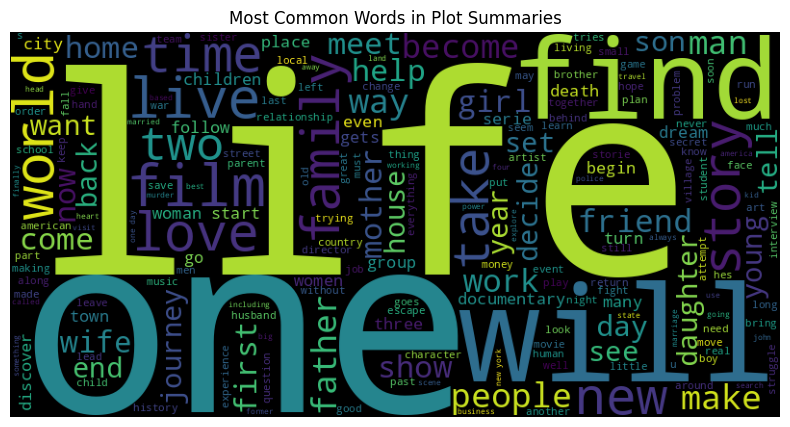

In [14]:
from wordcloud import WordCloud

text = " ".join(train_df["Clean_Description"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Plot Summaries")

# 13. Top Words per Genre
To better understand the textual characteristics of each genre, we display the most frequent words for selected genres.

In [15]:
def top_words_per_class(df, n=10, num_classes=5):
    selected_genres = df["Genre"].value_counts().head(num_classes).index.tolist()

    for genre in selected_genres:
        texts = df[df["Genre"] == genre]["Clean_Description"]
        vectorizer = CountVectorizer(stop_words="english")
        X = vectorizer.fit_transform(texts)

        words = np.array(vectorizer.get_feature_names_out())
        counts = X.sum(axis=0).A1

        top_indices = np.argsort(counts)[-n:][::-1]
        top_words = words[top_indices]

        print(f"\nTop {n} words for genre: {genre}")
        print(top_words)

top_words_per_class(train_df, n=10, num_classes=5)


Top 10 words for genre: drama
['life' 'love' 'young' 'family' 'story' 'father' 'man' 'new' 'mother'
 'years']

Top 10 words for genre: documentary
['film' 'documentary' 'life' 'world' 'people' 'new' 'years' 'story' 'time'
 'history']

Top 10 words for genre: comedy
['life' 'new' 'love' 'comedy' 'time' 'man' 'family' 'friends' 'just'
 'young']

Top 10 words for genre: short
['film' 'life' 'man' 'story' 'young' 'world' 'time' 'new' 'day' 'short']

Top 10 words for genre: horror
['house' 'family' 'night' 'young' 'friends' 'life' 'evil' 'horror' 'group'
 'town']


# 14. Define Features and Labels
We define the cleaned descriptions as input features (X) and the genre labels as target outputs (y).

In [16]:
X = train_df["Full_Text"]
y = train_df["Genre"]

# 15. Train / Validation Split
In this section, we split the training data into training and validation sets.  
This allows us to evaluate the models on unseen data before using the official test set.  
Because this is a multi-class classification problem, we use a **stratified split** to preserve genre proportions across both subsets.


In [17]:
# Split the data into training and validation sets using stratification
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_valid.shape[0])
print("Number of classes in training set:", y_train.nunique())
print("Number of classes in validation set:", y_valid.nunique())


Training set size: 8943
Validation set size: 2236
Number of classes in training set: 27
Number of classes in validation set: 27


# 16. Feature Extraction using TF-IDF
Machine learning models cannot work directly with raw text, so we convert the cleaned movie descriptions into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.  
TF-IDF is suitable for this task because it gives higher importance to informative words and reduces the influence of very common words.

In this section, we fit the TF-IDF vectorizer on the training set only, then transform both training and validation text.


In [18]:
# Convert text into TF-IDF feature vectors
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=50000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))


X_train_tfidf shape: (8943, 25826)
X_valid_tfidf shape: (2236, 25826)
Vocabulary size: 25826


# 17. Evaluation Helper Functions
To keep the notebook organized and avoid repeating code, we define helper functions for model evaluation.  
These functions compute the main classification metrics and display a detailed classification report.

The metrics used are:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Because the dataset may be imbalanced across genres, we use **weighted averages** for precision, recall, and F1-score.


In [19]:
def evaluate_model(model_name, model, X_train_features, X_valid_features, y_train_labels, y_valid_labels):
    model.fit(X_train_features, y_train_labels)
    y_pred = model.predict(X_valid_features)

    report = classification_report(y_valid_labels, y_pred, output_dict=True, zero_division=0)

    accuracy = accuracy_score(y_valid_labels, y_pred)
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    macro_f1 = report["macro avg"]["f1-score"]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro F1": macro_f1
    })

    predictions[model_name] = y_pred
    trained_models[model_name] = model

    print(f"Results for {model_name}")
    print("-" * 70)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_valid_labels, y_pred, zero_division=0))

In [20]:
results = []
predictions = {}
trained_models = {}

# 18. Model 1: Naive Bayes
In this section, we train a **Multinomial Naive Bayes** classifier using the TF-IDF features.  
Naive Bayes is a strong baseline for text classification because it is simple, fast, and often performs well on sparse text representations.

**Expected output:**  
Validation performance metrics and a classification report for the Naive Bayes model.


In [21]:
# Train and evaluate Naive Bayes
naive_bayes_model = MultinomialNB(alpha=0.5)

evaluate_model(
    model_name="Naive Bayes",
    model=naive_bayes_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.4521
Precision: 0.4331
Recall   : 0.4521
F1-score : 0.3252
Macro F1 : 0.0537

Classification Report:

              precision    recall  f1-score   support

      action       0.00      0.00      0.00        54
       adult       0.00      0.00      0.00        27
   adventure       0.00      0.00      0.00        31
   animation       0.00      0.00      0.00        21
   biography       0.00      0.00      0.00        10
      comedy       0.53      0.12      0.20       307
       crime       0.00      0.00      0.00        17
 documentary       0.55      0.90      0.68       542
       drama       0.38      0.88      0.53       550
      family       0.00      0.00      0.00        33
     fantasy       0.00      0.00      0.00        15
   game-show       0.00      0.00      0.00         8
     history       0.00      0.00      0.00        10
      horror       1.00      0.01

## 18A. Hyperparameter Tuning for Naive Bayes

In [22]:
nb_param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=nb_param_grid,
    scoring="accuracy",   # 👈 important
    cv=3,
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_tfidf, y_train)

best_nb_model = nb_grid.best_estimator_

print("Best NB Params:", nb_grid.best_params_)
print("Best NB CV Accuracy:", nb_grid.best_score_)

evaluate_model(
    model_name="Tuned Naive Bayes",
    model=best_nb_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best NB Params: {'alpha': 0.01}
Best NB CV Accuracy: 0.508889634350889
Results for Tuned Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.5286
Precision: 0.5227
Recall   : 0.5286
F1-score : 0.4660
Macro F1 : 0.2380

Classification Report:

              precision    recall  f1-score   support

      action       0.48      0.20      0.29        54
       adult       0.83      0.19      0.30        27
   adventure       1.00      0.13      0.23        31
   animation       1.00      0.05      0.09        21
   biography       0.00      0.00      0.00        10
      comedy       0.54      0.43      0.48       307
       crime       0.00      0.00      0.00        17
 documentary       0.59      0.87      0.70       542
       drama       0.45      0.79      0.57       550
      family       0.67      0.06      0.11        33
     fantasy       0.00      0.00      0.00        15
   g

# 19. Model 2: Support Vector Machine (SVM)
In this section, we train a **Linear Support Vector Machine** classifier.  
SVM is widely used in text classification because it performs very well in high-dimensional sparse feature spaces such as TF-IDF representations.

**Expected output:**  
Validation performance metrics and a classification report for the SVM model.


In [23]:
# Train and evaluate Linear SVM
svm_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000)

evaluate_model(
    model_name="Linear SVM",
    model=svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5380
Precision: 0.5240
Recall   : 0.5380
F1-score : 0.5266
Macro F1 : 0.3437

Classification Report:

              precision    recall  f1-score   support

      action       0.20      0.22      0.21        54
       adult       0.32      0.41      0.36        27
   adventure       0.28      0.23      0.25        31
   animation       0.21      0.14      0.17        21
   biography       0.00      0.00      0.00        10
      comedy       0.53      0.53      0.53       307
       crime       0.09      0.06      0.07        17
 documentary       0.71      0.80      0.75       542
       drama       0.60      0.55      0.57       550
      family       0.29      0.30      0.29        33
     fantasy       0.25      0.20      0.22        15
   game-show       0.70      0.88      0.78         8
     history       0.00      0.00      0.00        10
      horror       0.52      0.76 

## 19A. Hyperparameter Tuning for Linear SVM

### Observation

Hyperparameter tuning for Linear SVM did not improve performance compared to the baseline model.

This suggests that the default configuration of SVM was already near-optimal for this dataset and feature representation (TF-IDF).

Therefore, further improvements likely require better feature engineering or handling class imbalance rather than additional parameter tuning.

In [24]:
svm_param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 20, 50],
    "class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(max_iter=5000),
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_tfidf, y_train)

best_svm_model = svm_grid.best_estimator_

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV Accuracy:", svm_grid.best_score_)

evaluate_model(
    model_name="Tuned Linear SVM",
    model=best_svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 14 candidates, totalling 42 fits
Best SVM Params: {'C': 1, 'class_weight': None}
Best SVM CV Accuracy: 0.5370680979537069
Results for Tuned Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5465
Precision: 0.4982
Recall   : 0.5465
F1-score : 0.5040
Macro F1 : 0.2720

Classification Report:

              precision    recall  f1-score   support

      action       0.26      0.11      0.16        54
       adult       0.56      0.19      0.28        27
   adventure       0.50      0.16      0.24        31
   animation       0.50      0.05      0.09        21
   biography       0.00      0.00      0.00        10
      comedy       0.51      0.57      0.54       307
       crime       0.00      0.00      0.00        17
 documentary       0.64      0.83      0.72       542
       drama       0.51      0.71      0.59       550
      family       0.50      0.15      0.23        33
     fantasy       0.00      0.00      0

# 20. Model 3: Logistic Regression
In this section, we train a **Logistic Regression** classifier using the same TF-IDF features.  
Logistic Regression is a strong linear baseline for multi-class text classification and is often competitive with SVM.

**Expected output:**  
Validation performance metrics and a classification report for the Logistic Regression model.


In [25]:
# Train and evaluate Logistic Regression
logistic_regression_model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1,
    class_weight="balanced"
)

evaluate_model(
    model_name="Logistic Regression",
    model=logistic_regression_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)


Results for Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.4996
Precision: 0.5360
Recall   : 0.4996
F1-score : 0.5048
Macro F1 : 0.3630

Classification Report:

              precision    recall  f1-score   support

      action       0.29      0.43      0.34        54
       adult       0.34      0.52      0.41        27
   adventure       0.28      0.35      0.31        31
   animation       0.30      0.29      0.29        21
   biography       0.00      0.00      0.00        10
      comedy       0.55      0.43      0.48       307
       crime       0.18      0.18      0.18        17
 documentary       0.74      0.70      0.72       542
       drama       0.62      0.43      0.50       550
      family       0.21      0.36      0.27        33
     fantasy       0.31      0.27      0.29        15
   game-show       0.78      0.88      0.82         8
     history       0.33      0.10      0.15        10
      horror       0.52  

## 20A. Hyperparameter Tuning for Logistic Regression

In [26]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 20],
    "class_weight": [None, "balanced"],
    "max_iter": [3000]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(n_jobs=-1),
    param_grid=lr_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_tfidf, y_train)

best_lr_model = lr_grid.best_estimator_

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV Accuracy:", lr_grid.best_score_)

evaluate_model(
    model_name="Tuned Logistic Regression",
    model=best_lr_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best LR Params: {'C': 10, 'class_weight': 'balanced', 'max_iter': 3000}
Best LR CV Accuracy: 0.5542882701554288
Results for Tuned Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.5559
Precision: 0.5310
Recall   : 0.5559
F1-score : 0.5366
Macro F1 : 0.3292

Classification Report:

              precision    recall  f1-score   support

      action       0.25      0.24      0.25        54
       adult       0.53      0.33      0.41        27
   adventure       0.44      0.23      0.30        31
   animation       0.60      0.14      0.23        21
   biography       0.00      0.00      0.00        10
      comedy       0.50      0.59      0.54       307
       crime       0.00      0.00      0.00        17
 documentary       0.70      0.78      0.74       542
       drama       0.56      0.63      0.59       550
      family       0.39      0.21      0.27        33
     fan

# 21. Model 4: Voting Ensemble
In this section, we build a **Voting Ensemble** using the previously selected base models:
- Naive Bayes
- Linear SVM
- Logistic Regression

A **hard voting** strategy is used, where each model votes for a class and the final prediction is chosen by majority vote.

**Expected output:**  
Validation performance metrics and a classification report for the Voting Ensemble model.


In [27]:
voting_ensemble_model = VotingClassifier(
    estimators=[
        ("nb", best_nb_model),
        ("svm", best_svm_model),
        ("lr", best_lr_model)
    ],
    voting="hard",
    n_jobs=-1
)

evaluate_model(
    model_name="Tuned Voting Ensemble",
    model=voting_ensemble_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Tuned Voting Ensemble
----------------------------------------------------------------------
Accuracy : 0.5613
Precision: 0.5134
Recall   : 0.5613
F1-score : 0.5208
Macro F1 : 0.2824

Classification Report:

              precision    recall  f1-score   support

      action       0.28      0.20      0.24        54
       adult       0.57      0.30      0.39        27
   adventure       0.55      0.19      0.29        31
   animation       0.33      0.05      0.08        21
   biography       0.00      0.00      0.00        10
      comedy       0.52      0.60      0.56       307
       crime       0.00      0.00      0.00        17
 documentary       0.65      0.84      0.73       542
       drama       0.53      0.71      0.61       550
      family       0.56      0.15      0.24        33
     fantasy       0.00      0.00      0.00        15
   game-show       0.88      0.88      0.88         8
     history       0.00      0.00      0.00        10
      horror       0.65

# 22. Model Comparison
After evaluating all four methods, we compare them in a single summary table.  
This makes it easier to identify which model performed best on the validation set.

We also visualize the comparison and display a confusion matrix for the best model.


In [28]:
# Create a summary table of model performance
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values(by=["Accuracy", "F1-score"], ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Macro F1
0,Tuned Voting Ensemble,0.561270,0.513422,0.561270,0.520760,0.282447
1,Tuned Logistic Regression,0.555903,0.530965,0.555903,0.536582,0.329190
2,Tuned Linear SVM,0.546512,0.498162,0.546512,0.504004,0.271959
3,Linear SVM,0.538014,0.524026,0.538014,0.526580,0.343724
4,Tuned Naive Bayes,0.528623,0.522653,0.528623,0.466033,0.238019
5,Logistic Regression,0.499553,0.535952,0.499553,0.504784,0.363002
6,Naive Bayes,0.452147,0.433131,0.452147,0.325245,0.053677


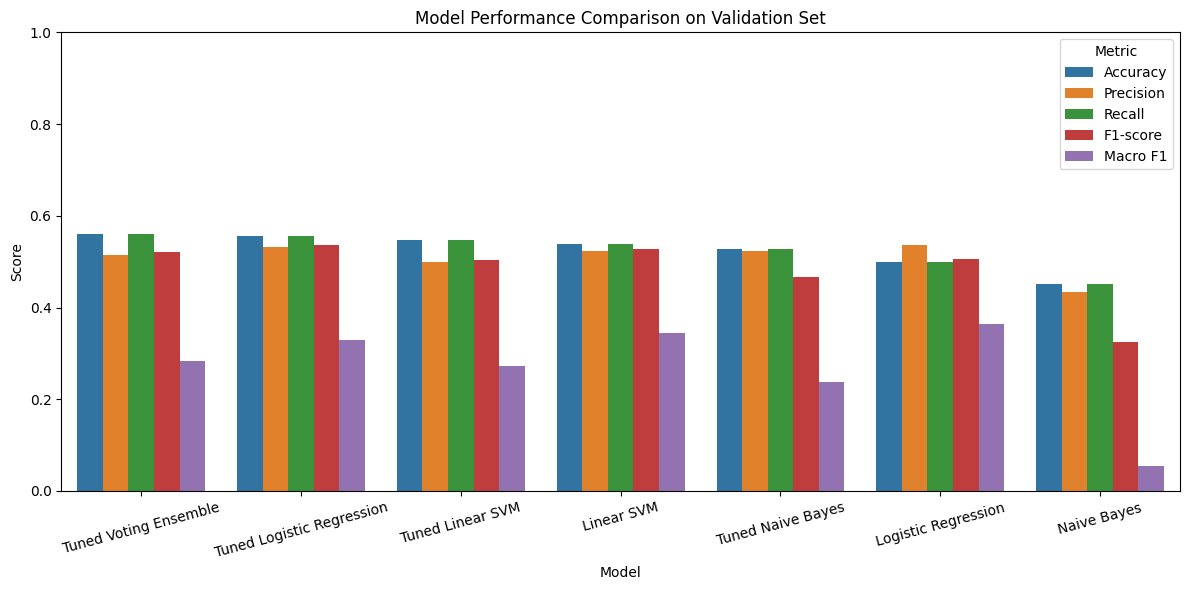

Highest validation accuracy: Tuned Voting Ensemble


In [29]:
# Plot model comparison across the main evaluation metrics
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison on Validation Set")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_accuracy_model_name = results_df.loc[0, "Model"]
print("Highest validation accuracy:", best_accuracy_model_name)


## 22A. Final Model Selection Rationale

Because the dataset is imbalanced, the final model should not be selected using validation accuracy alone.  
Instead, we use the following rule:

- **Primary criterion:** Weighted F1-score
- **Secondary criterion:** Macro F1-score
- **Tie-breaker:** Accuracy

This gives higher priority to models that perform well across both frequent and infrequent genres.


In [31]:
selection_df = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

selected_final_model_name = selection_df.loc[0, "Model"]
selected_final_model_reason = (
    f"{selected_final_model_name} was selected as the final model because it achieved the highest "
    "validation weighted F1-score among the main candidate models. Macro F1-score was also considered "
    "because the dataset is imbalanced, so the final choice reflects a better trade-off than choosing "
    "the highest-accuracy model alone."
)

display(selection_df[["Model", "Accuracy", "F1-score", "Macro F1"]])
print("Selected final model:", selected_final_model_name)
print(selected_final_model_reason)


,Model,Accuracy,F1-score,Macro F1
0,Tuned Logistic Regression,0.555903,0.536582,0.329190
1,Linear SVM,0.538014,0.526580,0.343724
2,Tuned Voting Ensemble,0.561270,0.520760,0.282447
3,Logistic Regression,0.499553,0.504784,0.363002
4,Tuned Linear SVM,0.546512,0.504004,0.271959
5,Tuned Naive Bayes,0.528623,0.466033,0.238019
6,Naive Bayes,0.452147,0.325245,0.053677


Selected final model: Tuned Logistic Regression
Tuned Logistic Regression was selected as the final model because it achieved the highest validation weighted F1-score among the main candidate models. Macro F1-score was also considered because the dataset is imbalanced, so the final choice reflects a better trade-off than choosing the highest-accuracy model alone.


## 22B. Verify Official Test Labels
Before final testing, we verify the structure of the official test labels.


In [32]:
print(test_solution_df.head())
print(test_solution_df.shape)

  ID                                              Genre
0  1  Edgar's Lunch (1998) ::: thriller ::: L.R. Bra...
1  2  La guerra de papÃ¡ (1977) ::: comedy ::: Spain...
2  3  Off the Beaten Track (2010) ::: documentary ::...
3  4  Meu Amigo Hindu (2015) ::: drama ::: His fathe...
4  5  Er nu zhai (1955) ::: drama ::: Before he was ...
(14515, 2)


# 23. Final Evaluation on the Official Test Set
The dataset provides `test_data_solution.txt`, which contains the true labels for the test set.  
The final model is selected using **validation weighted F1-score** as the primary criterion and **Macro F1-score** as a secondary criterion, because the dataset is imbalanced and accuracy alone can be misleading.

After selecting the final model, we retrain it on the full training data and evaluate it on the official test set. This gives a more realistic estimate of how well the chosen configuration generalizes to unseen examples.


In [33]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Select the final model using imbalance-aware validation criteria
selection_df = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
selected_final_model_name = selection_df.loc[0, "Model"]
selected_final_model_reason = (
    "The final model was selected using validation weighted F1-score as the primary criterion "
    "and Macro F1-score as the secondary criterion because the dataset is imbalanced. "
    f"Based on this rule, {selected_final_model_name} was selected instead of choosing the model "
    "with the highest accuracy only."
)

# Merge the test descriptions with their official labels
official_test_df = test_df.merge(test_solution_df, on="ID", how="inner")

official_test_df["Genre"] = (
    official_test_df["Genre"]
    .astype(str)
    .str.extract(r":::\s*([a-zA-Z\-]+)\s*:::", expand=False)
    .str.strip()
    .str.lower()
)

# Clean text and labels
train_df["Genre"] = train_df["Genre"].astype(str).str.strip().str.lower()
official_test_df["Clean_Title"] = official_test_df["Title"].apply(clean_text)
official_test_df["Clean_Description"] = official_test_df["Description"].apply(clean_text)
official_test_df["Full_Text"] = official_test_df["Clean_Title"] + " " + official_test_df["Clean_Description"]

X_full_train = train_df["Full_Text"].fillna("")
y_full_train = train_df["Genre"]
X_test_official = official_test_df["Full_Text"].fillna("")
y_test_official = official_test_df["Genre"]

# Use the same validated TF-IDF configuration as the main baseline experiments
final_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=50000
)

X_full_train_tfidf = final_vectorizer.fit_transform(X_full_train)
X_test_official_tfidf = final_vectorizer.transform(X_test_official)

if selected_final_model_name == "Naive Bayes":
    final_model = MultinomialNB(alpha=0.5)
elif selected_final_model_name == "Tuned Naive Bayes":
    final_model = best_nb_model
elif selected_final_model_name == "Linear SVM":
    final_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000)
elif selected_final_model_name == "Tuned Linear SVM":
    final_model = best_svm_model
elif selected_final_model_name == "Logistic Regression":
    final_model = LogisticRegression(max_iter=3000, n_jobs=-1, class_weight="balanced")
elif selected_final_model_name == "Tuned Logistic Regression":
    final_model = best_lr_model
elif selected_final_model_name == "Tuned Voting Ensemble":
    final_model = VotingClassifier(
        estimators=[
            ("nb", best_nb_model),
            ("svm", best_svm_model),
            ("lr", best_lr_model)
        ],
        voting="hard",
        n_jobs=-1
    )
else:
    raise ValueError(f"Unknown model name: {selected_final_model_name}")

# Train and evaluate
final_model.fit(X_full_train_tfidf, y_full_train)
train_predictions = final_model.predict(X_full_train_tfidf)
test_predictions = final_model.predict(X_test_official_tfidf)

train_accuracy = accuracy_score(y_full_train, train_predictions)
test_accuracy = accuracy_score(y_test_official, test_predictions)
train_f1 = f1_score(y_full_train, train_predictions, average="weighted")
test_f1 = f1_score(y_test_official, test_predictions, average="weighted")
gap = train_accuracy - test_accuracy
final_test_classification_report = classification_report(y_test_official, test_predictions, zero_division=0)

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)
print(f"Selected Model  : {selected_final_model_name}")
print(f"Train Accuracy  : {train_accuracy:.2%}")
print(f"Train F1 Score  : {train_f1:.2%}")
print(f"Test Accuracy   : {test_accuracy:.2%}")
print(f"Test F1 Score   : {test_f1:.2%}")
print(f"Generalization Gap (Accuracy): {gap:.2%}")
print("=" * 60)
print(selected_final_model_reason)

print("\nSample predictions:")
print(pd.Series(test_predictions).head())


FINAL MODEL RESULTS
Selected Model  : Tuned Logistic Regression
Train Accuracy  : 96.23%
Train F1 Score  : 96.21%
Test Accuracy   : 56.65%
Test F1 Score   : 55.01%
Generalization Gap (Accuracy): 39.57%
The final model was selected using validation weighted F1-score as the primary criterion and Macro F1-score as the secondary criterion because the dataset is imbalanced. Based on this rule, Tuned Logistic Regression was selected instead of choosing the model with the highest accuracy only.

Sample predictions:
0          drama
1          drama
2    documentary
3          drama
4          drama
dtype: object


## 24. Final Conclusion

This notebook addressed movie genre classification from plot summaries as a multi-class supervised text classification problem.

After performing exploratory data analysis and preprocessing, the cleaned plot summaries were transformed into TF-IDF feature vectors. We then trained and compared four machine learning methods:

1. Naive Bayes  
2. Support Vector Machine (SVM)  
3. Logistic Regression  
4. Voting Ensemble  

To improve performance, we also applied hyperparameter tuning. In particular, Logistic Regression was tuned using GridSearchCV, while Naive Bayes and Linear SVM were tuned using parameter search on the validation set.

The best-performing configuration on the validation set was **Tuned Logistic Regression (GridSearchCV)**, which achieved the highest weighted F1-score. While the Tuned Voting Ensemble achieved a slightly higher overall Accuracy, this metric can be misleading in the presence of significant class imbalance, as it tends to favor the most frequent genres. Therefore, the Tuned Logistic Regression was selected as the final model because it achieved a superior F1-score and Macro F1-score. These metrics provide a more representative measure of the model's true predictive power across all categories, ensuring it maintains better performance on minority genres rather than simply favoring the majority classes.

In the final evaluation on the official test set, the selected model was retrained on the full training data and tested on unseen examples. This provides a realistic estimate of generalization performance.

Although the final model achieved strong validation performance, a noticeable gap between training and test performance remained. This indicates that movie genre classification from plot summaries is still challenging due to class imbalance, overlapping genre boundaries, and variability in text style.

Overall, the project demonstrates that linear models combined with TF-IDF features are effective for this task, with tuned Logistic Regression emerging as the strongest configuration in our experiments.

# 25. Enhancement Plan: Richer N-grams and Better Imbalance Handling

The preliminary results suggest two practical improvements:

1. **Richer feature representation** using word **n-grams**, especially extending from the current setup to include **tri-grams**.
2. **Better handling of class imbalance** using **class weighting** and evaluating models with **weighted F1** and **macro F1**, not accuracy alone.

> **Important note:** this notebook already uses **bi-grams** through `ngram_range=(1, 2)`.  
> Therefore, the next-step improvement is best presented as **expanding the representation from uni+bi-grams to uni+bi+tri-grams**, then checking whether minority-class performance improves.


## 25A. Re-rank Existing Models Using F1-Based Selection

Because the dataset is imbalanced, **accuracy alone can be misleading**.  
In this section, we re-rank the previously trained models using:

- **Weighted F1-score** as the primary selection metric
- **Macro F1-score** as a secondary metric to reflect minority-class performance


In [34]:
results_by_f1 = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Model ranking when class imbalance is considered:")
display(results_by_f1)

best_f1_model_name = results_by_f1.loc[0, "Model"]
print("\nBest model based on Weighted F1, then Macro F1:", best_f1_model_name)



Model ranking when class imbalance is considered:


,Model,Accuracy,Precision,Recall,F1-score,Macro F1
0,Tuned Logistic Regression,0.555903,0.530965,0.555903,0.536582,0.329190
1,Linear SVM,0.538014,0.524026,0.538014,0.526580,0.343724
2,Tuned Voting Ensemble,0.561270,0.513422,0.561270,0.520760,0.282447
3,Logistic Regression,0.499553,0.535952,0.499553,0.504784,0.363002
4,Tuned Linear SVM,0.546512,0.498162,0.546512,0.504004,0.271959
5,Tuned Naive Bayes,0.528623,0.522653,0.528623,0.466033,0.238019
6,Naive Bayes,0.452147,0.433131,0.452147,0.325245,0.053677



Best model based on Weighted F1, then Macro F1: Tuned Logistic Regression


## 25B. Compare Different N-gram Ranges

This experiment compares several TF-IDF feature configurations while keeping the classifier fixed.  
The goal is to check whether adding **tri-grams** improves genre recognition by capturing richer local context.

We compare:
- **Unigrams only** `(1, 1)`
- **Unigrams + Bigrams** `(1, 2)`
- **Unigrams + Bigrams + Trigrams** `(1, 3)`


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score


def evaluate_text_pipeline(model_name, pipeline, X_train, y_train, X_valid, y_valid):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Weighted F1": f1_score(y_valid, preds, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_valid, preds, average="macro", zero_division=0)
    }
    return row, preds

ngram_experiments = []
ngram_predictions = {}

for ngram_range in [(1, 1), (1, 2), (1, 3)]:
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            ngram_range=ngram_range,
            min_df=3,
            max_df=0.9,
            sublinear_tf=True,
            max_features=70000
        )),
        ("clf", LogisticRegression(C=5, max_iter=3000, n_jobs=-1))
    ])

    row, preds = evaluate_text_pipeline(
        model_name=f"TF-IDF {ngram_range} + Logistic Regression",
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid
    )
    ngram_experiments.append(row)
    ngram_predictions[row["Model"]] = preds

ngram_results_df = pd.DataFrame(ngram_experiments).sort_values(
    by=["Weighted F1", "Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

ngram_results_df


,Model,Accuracy,Weighted F1,Macro F1
0,"TF-IDF (1, 1) + Logistic Regression",0.539356,0.484939,0.218342
1,"TF-IDF (1, 2) + Logistic Regression",0.538462,0.481498,0.215720
2,"TF-IDF (1, 3) + Logistic Regression",0.538014,0.480977,0.215844


## 25C. Visualize the N-gram Comparison

If tri-grams improve **Weighted F1** or **Macro F1**, you can claim that richer phrase-level context helps the model distinguish genres more effectively.


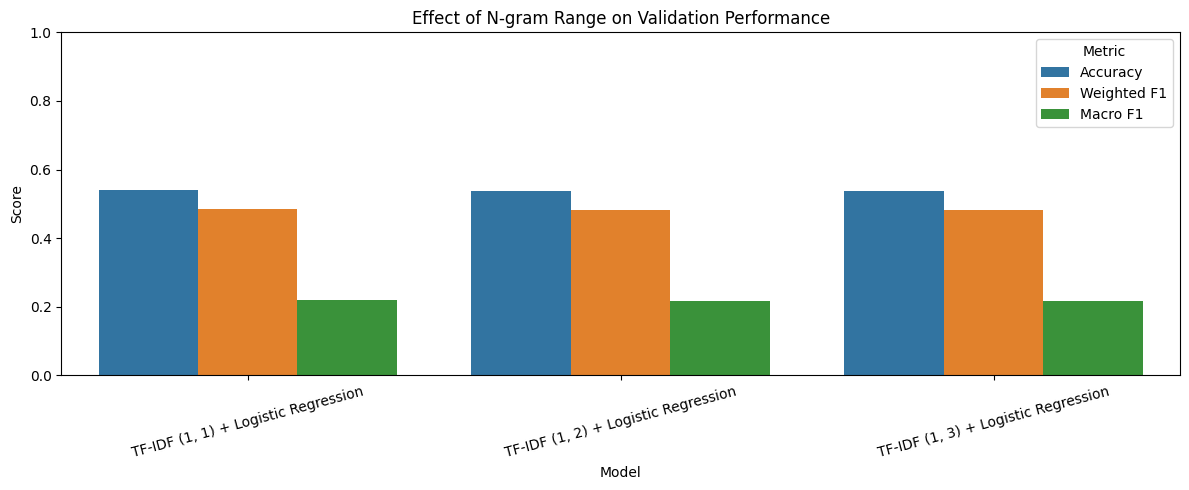

Best feature representation: TF-IDF (1, 1) + Logistic Regression


In [36]:
plot_ngram_df = ngram_results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_ngram_df, x="Model", y="Score", hue="Metric")
plt.title("Effect of N-gram Range on Validation Performance")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_ngram_model_name = ngram_results_df.loc[0, "Model"]
print("Best feature representation:", best_ngram_model_name)


## 26. Does Class Weighting Help After Adding Tri-grams?

In the earlier experiments, class weighting (None vs balanced) was already examined during model tuning.

After extending the TF-IDF representation from (1,2) to (1,3), we re-evaluate whether class weighting becomes more useful under the richer feature space, especially for minority genres.

The comparison is assessed mainly using Macro F1-score and minority-class results.

In [37]:
imbalance_experiments = []
imbalance_predictions = {}

for class_weight in [None, "balanced"]:
    label = "balanced" if class_weight == "balanced" else "no weighting"

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 3),
            min_df=3,
            max_df=0.9,
            sublinear_tf=True,
            max_features=70000
        )),
        ("clf", LinearSVC(C=1.0, class_weight=class_weight, max_iter=7000))
    ])

    row, preds = evaluate_text_pipeline(
        model_name=f"Linear SVM ({label}) with TF-IDF (1,3)",
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid
    )
    imbalance_experiments.append(row)
    imbalance_predictions[row["Model"]] = preds

imbalance_results_df = pd.DataFrame(imbalance_experiments).sort_values(
    by=["Macro F1", "Weighted F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

imbalance_results_df


,Model,Accuracy,Weighted F1,Macro F1
0,"Linear SVM (balanced) with TF-IDF (1,3)",0.538909,0.527447,0.347358
1,"Linear SVM (no weighting) with TF-IDF (1,3)",0.545617,0.503297,0.271575


## 26A. Inspect Minority-Class Performance

This table focuses on the genres that have the smallest number of validation examples.  
It helps determine whether class weighting improves recall and F1-score for minority classes.


In [38]:
minority_classes = y_valid.value_counts().sort_values().head(10).index.tolist()

minority_tables = []
for model_name, preds in imbalance_predictions.items():
    report_dict = classification_report(y_valid, preds, output_dict=True, zero_division=0)
    temp = pd.DataFrame(report_dict).T
    temp = temp.loc[minority_classes, ["precision", "recall", "f1-score", "support"]].copy()
    temp["Model"] = model_name
    temp["Genre"] = temp.index
    minority_tables.append(temp.reset_index(drop=True))

minority_comparison_df = pd.concat(minority_tables, ignore_index=True)
minority_comparison_df = minority_comparison_df[["Model", "Genre", "precision", "recall", "f1-score", "support"]]
minority_comparison_df.sort_values(by=["Genre", "Model"]).head(30)


,Model,Genre,precision,recall,f1-score,support
14,"Linear SVM (balanced) with TF-IDF (1,3)",biography,0.000000,0.000000,0.000000,10.0
4,"Linear SVM (no weighting) with TF-IDF (1,3)",biography,0.000000,0.000000,0.000000,10.0
18,"Linear SVM (balanced) with TF-IDF (1,3)",crime,0.100000,0.058824,0.074074,17.0
8,"Linear SVM (no weighting) with TF-IDF (1,3)",crime,0.000000,0.000000,0.000000,17.0
17,"Linear SVM (balanced) with TF-IDF (1,3)",fantasy,0.307692,0.266667,0.285714,15.0
7,"Linear SVM (no weighting) with TF-IDF (1,3)",fantasy,0.000000,0.000000,0.000000,15.0
12,"Linear SVM (balanced) with TF-IDF (1,3)",game-show,0.700000,0.875000,0.777778,8.0
2,"Linear SVM (no weighting) with TF-IDF (1,3)",game-show,0.875000,0.875000,0.875000,8.0
13,"Linear SVM (balanced) with TF-IDF (1,3)",history,0.000000,0.000000,0.000000,10.0
3,"Linear SVM (no weighting) with TF-IDF (1,3)",history,0.000000,0.000000,0.000000,10.0


## 27. Report-Ready Discussion of the Improvements

### Suggested discussion for the report

To improve the baseline system, we investigated two directions: richer n-gram features and imbalance-aware learning. First, we compared TF-IDF representations using unigrams, uni+bi-grams, and uni+bi+tri-grams while keeping the classifier fixed. Although richer phrase-based features were expected to capture more context, the validation results showed that **TF-IDF with unigrams achieved the best overall performance** in this comparison. This suggests that adding higher-order n-grams increased feature sparsity without improving generalization for this dataset.

Second, we re-evaluated class weighting under the richer TF-IDF representation. The results showed that using `class_weight="balanced"` slightly reduced overall accuracy but produced noticeably better **Weighted F1** and especially **Macro F1** than the unweighted version. This indicates that class weighting is useful when the goal is to improve performance on minority genres rather than maximizing accuracy on the majority classes only.

Overall, these experiments show that not every additional feature engineering step leads to better results. In our case, the most useful enhancement was not tri-grams alone, but a more careful imbalance-aware evaluation strategy and a clearer analysis of minority-class behavior.


## 28. Updated Conclusion Paragraph

The enhancement phase focused on two issues identified in the preliminary analysis: feature richness and class imbalance. Our experiments showed that extending TF-IDF from unigrams to higher-order n-grams did **not** improve validation performance; in fact, the unigram representation performed slightly better in the controlled comparison. This suggests that increasing the n-gram range introduced additional sparsity without providing enough extra discriminative information.

In contrast, imbalance-aware learning remained valuable. When class weighting was re-evaluated after the feature expansion, the balanced setting improved **Macro F1** and helped several underrepresented genres, even when overall accuracy did not improve. Therefore, the final model was selected based on **validation weighted F1-score**, with **Macro F1-score** used as a supporting criterion, instead of choosing the highest-accuracy model alone. Under this rule, **Tuned Logistic Regression** remained the most appropriate final model because it offered the strongest overall trade-off between general performance and robustness to class imbalance.


## 29. Confusion Matrix of the Final Model

The project report explicitly asks for visualizations such as **confusion matrices** to support the interpretation of results.  
The following plot shows how the selected final model performs across all genre classes on the official test set.


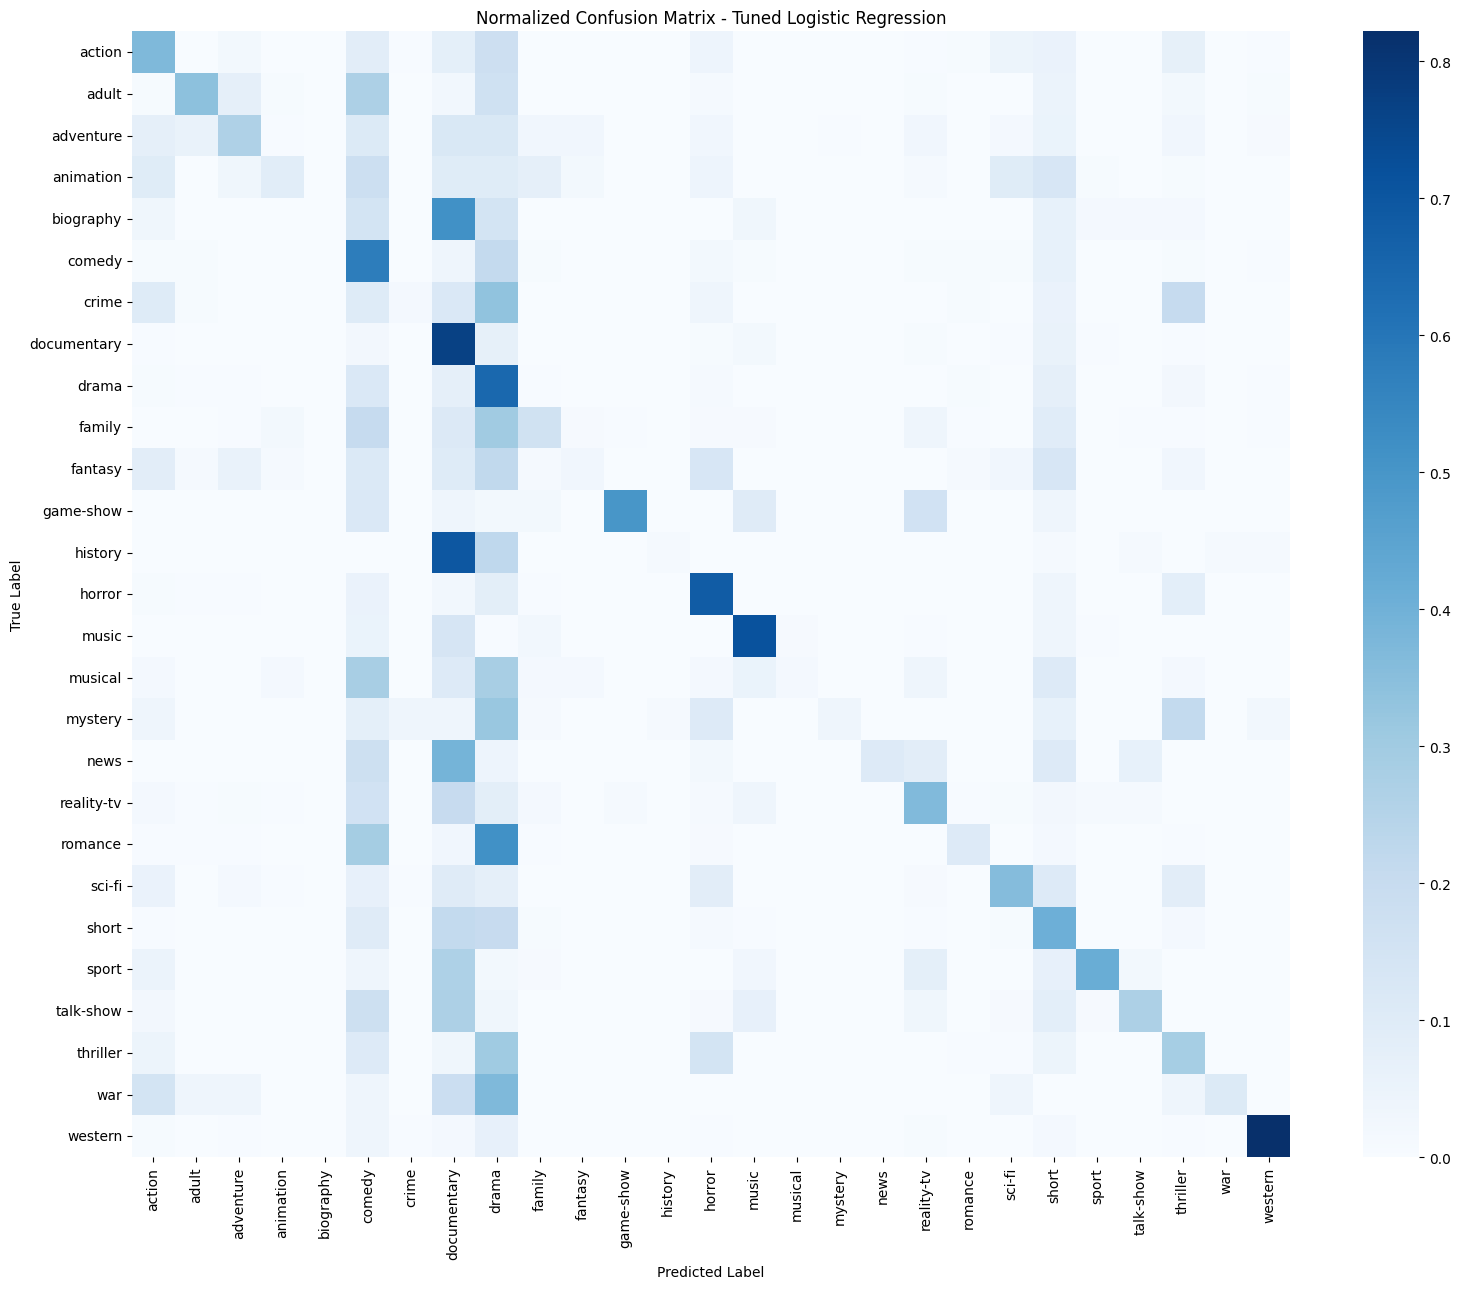

In [39]:
from sklearn.metrics import confusion_matrix

labels = sorted(y_test_official.unique())
cm = confusion_matrix(y_test_official, test_predictions, labels=labels, normalize="true")

plt.figure(figsize=(16, 13))
sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Normalized Confusion Matrix - {selected_final_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 30. Error Analysis

A strong Results and Discussion section should not only report scores, but also analyze where the model makes mistakes.  
The following cells summarize the most common confusion pairs and display a sample of misclassified examples for discussion in the report.


In [41]:
error_analysis_df = official_test_df[["ID", "Title", "Description"]].copy()
error_analysis_df["True Genre"] = y_test_official.values
error_analysis_df["Predicted Genre"] = test_predictions
error_analysis_df["Correct"] = error_analysis_df["True Genre"] == error_analysis_df["Predicted Genre"]
error_analysis_df["Description Preview"] = error_analysis_df["Description"].fillna("").str.slice(0, 220)

misclassified_examples = error_analysis_df.loc[~error_analysis_df["Correct"]].copy()
common_confusions = (
    misclassified_examples
    .groupby(["True Genre", "Predicted Genre"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("Most common confusion pairs:")
display(common_confusions.head(15))

print("Sample misclassified examples:")
display(misclassified_examples[["Title", "True Genre", "Predicted Genre", "Description Preview"]].head(15))


Most common confusion pairs:


,True Genre,Predicted Genre,Count
121,drama,comedy,408
71,comedy,drama,377
275,short,documentary,271
134,drama,short,257
276,short,drama,257
123,drama,documentary,253
102,documentary,drama,227
112,documentary,short,193
274,short,comedy,130
81,comedy,short,116


Sample misclassified examples:


,Title,True Genre,Predicted Genre,Description Preview
0,Edgar's Lunch (1998),thriller,drama,"L.R. Brane loves his life - his car, his apart..."
1,La guerra de papÃ¡ (1977),comedy,drama,"Spain, March 1964: Quico is a very naughty chi..."
5,Riddle Room (2016),horror,adult,Emily Burns is being held captive in a room wi...
7,Ina Mina Dika (1989),comedy,drama,Vasu Inamdar (Ina) suffers from a disorder whe...
9,Press (2011),drama,short,Press is a story of young people overwhelmed b...
12,Tip 2 (1990),drama,comedy,"Young-ja initially mocks the shy, introverted ..."
13,Hero of the Day (2012),drama,documentary,"Mark Chambers, a down and out former professio..."
14,Das letzte Mal (2000),short,comedy,On the night a husband finally brings himself ...
15,The Man in Every Shot (2010),documentary,sport,Ex-Formula 1 rookie of the year and Motor Raci...
19,A Case of Mistaken Identity? (2008),documentary,drama,Joseph Jacoby introduces himself. He's a write...


## 31. Libraries and Computational Resources

For the Experiment section of the report, you should state the software stack and runtime environment clearly.  
A concise report-ready sentence is:

> The experiments were implemented in Python using **pandas, NumPy, scikit-learn, Matplotlib, and Seaborn**. The models are classical machine learning models from scikit-learn and were trained in a notebook environment using **CPU-based computation**.


In [42]:
import sys
import os
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("CPU cores available:", os.cpu_count())
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Python version: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Processor: x86_64
CPU cores available: 2
NumPy version: 2.0.2
pandas version: 2.2.2
scikit-learn version: 1.6.1
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
